# HR Employee Attrition Prediction — Completed EDA & Preprocessing

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Source:** Kaggle — `pavansubhasht/ibm-hr-analytics-attrition-dataset`

In [1]:
!pip -q install kagglehub

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Colab/Kaggle path when available; local fallback for reproducibility outside Kaggle.
local_csv = "/mnt/data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
if os.path.exists(local_csv):
    dataset_path = os.path.dirname(local_csv)
else:
    import kagglehub
    dataset_path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Dataset directory:", dataset_path)

D:\APIs\First APi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset directory: C:\Users\Nishad's Lappi\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [3]:
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file was found. Upload WA_Fn-UseC_-HR-Employee-Attrition.csv or run in an environment with Kaggle access.")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("CSV used:", csv_path)
print("Shape:", df.shape)
display(df.head())

CSV used: C:\Users\Nishad's Lappi\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1\WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 1. Initial EDA — Dataset Structure

In [4]:
# Basic structure
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Number of rows: 1470
Number of columns: 35

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:


,dtype
Age,int64
Attrition,str
BusinessTravel,str
DailyRate,int64
Department,str
DistanceFromHome,int64
Education,int64
EducationField,str
EmployeeCount,int64
EmployeeNumber,int64


In [5]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
# Statistical summary
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [7]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [8]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_pct
})

display(missing_table[missing_table["Missing Count"] > 0])

if missing.sum() == 0:
    print("No missing values were found in the dataset.")

,Missing Count,Missing Percentage


No missing values were found in the dataset.


## 2. Target Variable Analysis

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: Percentage, dtype: float64

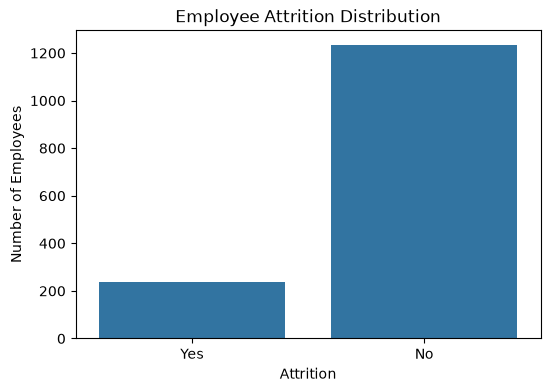

In [9]:
# Target distribution
display(df["Attrition"].value_counts())
display(df["Attrition"].value_counts(normalize=True).mul(100).round(2).rename("Percentage"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [10]:
# Numeric encoding only for quick analysis
target_map = {"No": 0, "Yes": 1}
df["Attrition_Binary"] = df["Attrition"].map(target_map)

print("Attrition rate:", round(df["Attrition_Binary"].mean() * 100, 2), "%")

Attrition rate: 16.12 %


## 3. Categorical and Numerical Features

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)

Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Binary']


C:\Users\Nishad's Lappi\AppData\Local\Temp\ipykernel_2452\822477310.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [12]:
# Cardinality of categorical variables
cat_cardinality = pd.DataFrame({
    "Unique Values": df[categorical_cols].nunique(),
    "Missing Values": df[categorical_cols].isnull().sum()
}).sort_values("Unique Values", ascending=False)

display(cat_cardinality)

,Unique Values,Missing Values
JobRole,9,0
EducationField,6,0
MaritalStatus,3,0
Department,3,0
BusinessTravel,3,0
Attrition,2,0
Gender,2,0
OverTime,2,0
Over18,1,0


## 4. Initial EDA — Important HR Relationships

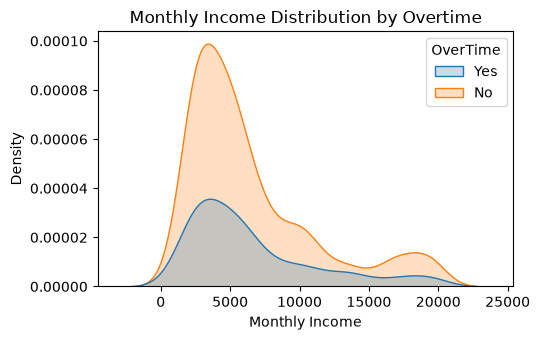

In [13]:
# Attrition by overtime
plt.figure(figsize=(5.5, 3.5))

sns.kdeplot(
    data=df,
    x="MonthlyIncome",
    hue="OverTime",
    fill=True
)

plt.title("Monthly Income Distribution by Overtime")
plt.xlabel("Monthly Income")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

,Level,Employees,AttritionRate
0,Level 1 (Very Low),289,22.8%
1,Level 2 (Low),280,16.4%
2,Level 3 (High),442,16.5%
3,Level 4 (Very High),459,11.3%


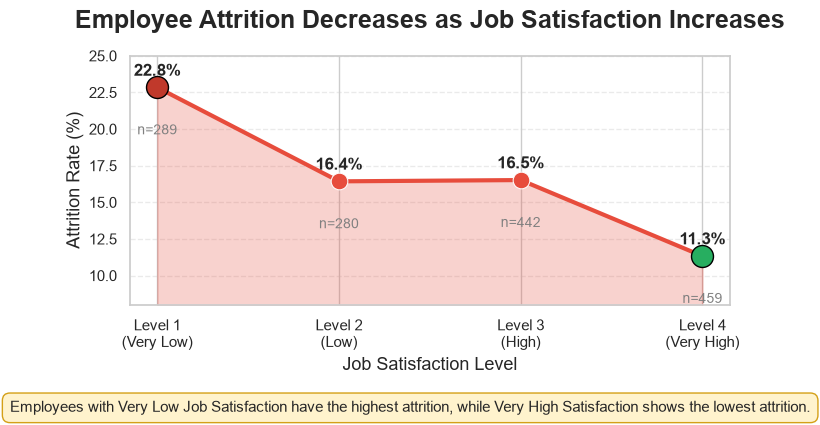

In [14]:
# Job Satisfaction vs Employee Attrition

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Calculate attrition percentage and employee count
summary = (
    df.groupby("JobSatisfaction")["Attrition"]
      .agg(
          AttritionRate=lambda x: (x == "Yes").mean() * 100,
          Employees="count"
      )
      .reset_index()
)

# Friendly labels
summary["Level"] = [
    "Level 1\n(Very Low)",
    "Level 2\n(Low)",
    "Level 3\n(High)",
    "Level 4\n(Very High)"
]

# Display summary table
display(summary[["Level", "Employees", "AttritionRate"]].style.format({
    "AttritionRate": "{:.1f}%"
}))

# Create figure
plt.figure(figsize=(7,4))

# Line plot
sns.lineplot(
    data=summary,
    x="Level",
    y="AttritionRate",
    marker="o",
    linewidth=3,
    markersize=12,
    color="#E74C3C"
)

# Fill area under the curve
plt.fill_between(
    range(len(summary)),
    summary["AttritionRate"],
    alpha=0.25,
    color="#E74C3C"
)

# Annotate each point
for i, row in summary.iterrows():
    plt.text(
        i,
        row["AttritionRate"] + 0.8,
        f"{row['AttritionRate']:.1f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    plt.text(
        i,
        row["AttritionRate"] - 3.2,
        f"n={row['Employees']}",
        ha="center",
        fontsize=10,
        color="gray"
    )

# Highlight highest and lowest
plt.scatter(
    summary["Level"].iloc[0],
    summary["AttritionRate"].iloc[0],
    s=250,
    color="#C0392B",
    edgecolor="black",
    zorder=5
)

plt.scatter(
    summary["Level"].iloc[-1],
    summary["AttritionRate"].iloc[-1],
    s=250,
    color="#27AE60",
    edgecolor="black",
    zorder=5
)

# Formatting
plt.title(
    "Employee Attrition Decreases as Job Satisfaction Increases",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Job Satisfaction Level", fontsize=13)
plt.ylabel("Attrition Rate (%)", fontsize=13)

plt.ylim(8,25)

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Insight box
plt.figtext(
    0.5,
    -0.05,
    "Employees with Very Low Job Satisfaction have the highest attrition, while Very High Satisfaction shows the lowest attrition.",
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5",
              facecolor="#FFF3CD",
              edgecolor="#D4A017")
)

plt.tight_layout()
plt.show()

,Attrition Rate (%)
BusinessTravel,
Non-Travel,8.00
Travel_Rarely,14.96
Travel_Frequently,24.91


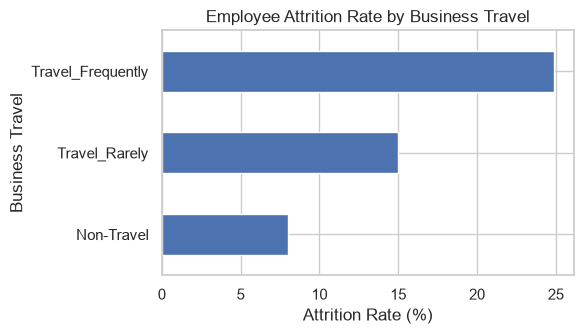

In [15]:
# Attrition by business travel — horizontal attrition-rate bar chart
travel_rate = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=True)
)

display(travel_rate.to_frame("Attrition Rate (%)").round(2))

plt.figure(figsize=(6, 3.5))
travel_rate.plot(kind="barh")
plt.title("Employee Attrition Rate by Business Travel")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Business Travel")
plt.tight_layout()
plt.show()

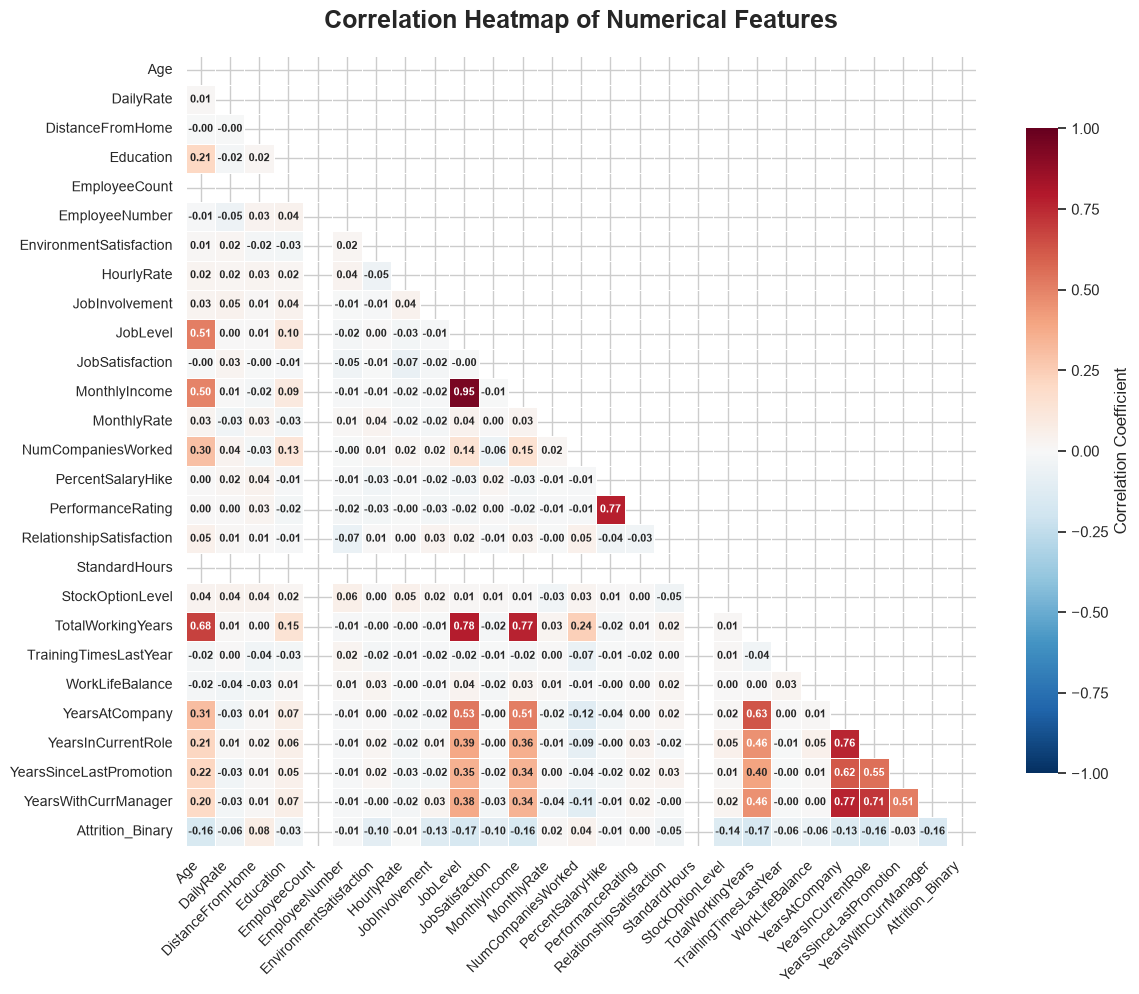

In [16]:
# Correlation Heatmap

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features only
numeric_for_corr = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = numeric_for_corr.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Correlation Coefficient",
        "shrink": 0.8
    },
    annot_kws={
        "size": 8,
        "weight": "bold"
    }
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## 4A. Additional Distribution and Relationship Plots

Different plot types are used for different analytical questions instead of repeatedly using countplots.


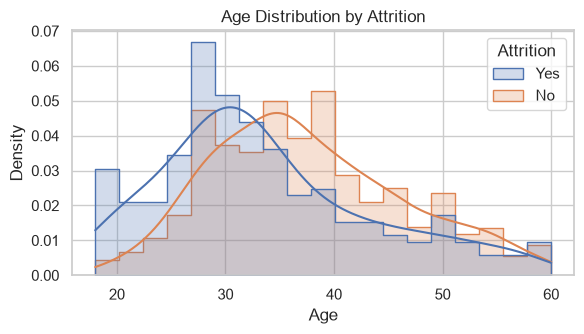

In [17]:
# Numerical distribution — histogram with KDE
plt.figure(figsize=(6, 3.5))
sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

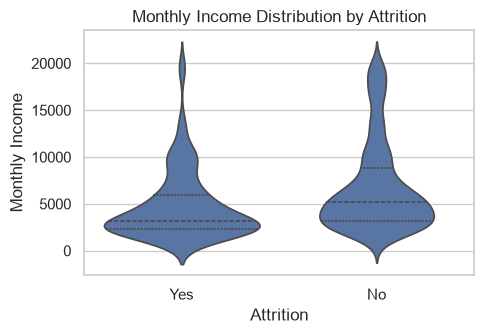

In [18]:
# Monthly income — violin plot
plt.figure(figsize=(5, 3.5))
sns.violinplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    inner="quartile"
)
plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

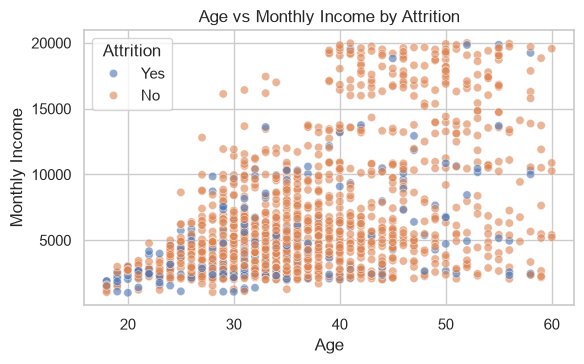

In [19]:
# Numerical relationship — scatter plot
plt.figure(figsize=(6, 3.8))
sns.scatterplot(
    data=df,
    x="Age",
    y="MonthlyIncome",
    hue="Attrition",
    alpha=0.6
)
plt.title("Age vs Monthly Income by Attrition")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()


## 5. Finalized Preprocessing

The finalized workflow keeps the untouched test set separate and uses leakage-safe preprocessing. Constant and identifier-like columns are removed automatically. Categorical variables are one-hot encoded. Numerical variables are scaled for distance/linear models. Tree-based models use the same one-hot representation but **do not use PCA**, because PCA can discard useful feature-level splits for tree learners.

In [20]:
# Finalized data cleaning and target encoding
data = df.copy()
data = data.drop(columns=["Attrition_Binary"], errors="ignore")

constant_columns = [
    col for col in data.columns
    if col != "Attrition" and data[col].nunique(dropna=False) <= 1
]
id_like_columns = [
    col for col in data.columns
    if col != "Attrition"
    and data[col].nunique(dropna=False) == len(data)
]
auto_drop_columns = sorted(set(constant_columns + id_like_columns))
data = data.drop(columns=auto_drop_columns, errors="ignore")
data["Attrition"] = data["Attrition"].map({"No": 0, "Yes": 1})

print("Dropped constant/ID-like columns:", auto_drop_columns)
print("Final raw modeling shape:", data.shape)

Dropped constant/ID-like columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Final raw modeling shape: (1470, 31)


In [21]:
# Domain-driven feature engineering
def add_hr_features(X):
    X = X.copy()

    # Career progression and tenure ratios
    X["YearsSincePromotionRatio"] = X["YearsSinceLastPromotion"] / (X["YearsAtCompany"] + 1)
    X["CurrentRoleRatio"] = X["YearsInCurrentRole"] / (X["YearsAtCompany"] + 1)
    X["ManagerTenureRatio"] = X["YearsWithCurrManager"] / (X["YearsAtCompany"] + 1)
    X["CompanyExperienceRatio"] = X["YearsAtCompany"] / (X["TotalWorkingYears"] + 1)

    # Compensation/experience relationships
    X["IncomePerJobLevel"] = X["MonthlyIncome"] / (X["JobLevel"] + 1)
    X["IncomePerYearExperience"] = X["MonthlyIncome"] / (X["TotalWorkingYears"] + 1)
    X["YearsAtCompanyRatioToAge"] = X["YearsAtCompany"] / (X["Age"] + 1)
    X["JobLevelPerYear"] = X["JobLevel"] / (X["TotalWorkingYears"] + 1)

    # Satisfaction and workload summaries
    satisfaction_cols = [
        "EnvironmentSatisfaction", "JobInvolvement", "JobSatisfaction",
        "RelationshipSatisfaction", "WorkLifeBalance"
    ]
    X["SatisfactionAvg"] = X[satisfaction_cols].mean(axis=1)
    X["WorkPressureScore"] = (
        X["OverTime"].map({"Yes": 1, "No": 0})
        + (4 - X["WorkLifeBalance"]) / 4
        + (4 - X["JobSatisfaction"]) / 4
    )

    # Simple career-stage indicators
    X["EarlyCareer"] = ((X["Age"] < 30) & (X["TotalWorkingYears"] < 5)).astype(int)
    X["FrequentJobChanges"] = (
        (X["NumCompaniesWorked"] >= 3) &
        (X["TotalWorkingYears"] <= 10)
    ).astype(int)

    # Interactions that are meaningful for attrition
    X["OverTime_JobSatisfaction"] = (
        X["OverTime"].astype(str) + "_" + X["JobSatisfaction"].astype(str)
    )
    X["OverTime_WorkLifeBalance"] = (
        X["OverTime"].astype(str) + "_" + X["WorkLifeBalance"].astype(str)
    )
    X["OverTime_JobLevel"] = (
        X["OverTime"].astype(str) + "_" + X["JobLevel"].astype(str)
    )
    X["Marital_OverTime"] = (
        X["MaritalStatus"].astype(str) + "_" + X["OverTime"].astype(str)
    )
    X["JobRole_OverTime"] = (
        X["JobRole"].astype(str) + "_" + X["OverTime"].astype(str)
    )

    return X

X = add_hr_features(data.drop(columns=["Attrition"]))
y = data["Attrition"]

print("Features after domain-driven engineering:", X.shape[1])

Features after domain-driven engineering: 47


In [22]:
# Leakage-safe 70/15/15 stratified split
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=(0.15 / 0.85), random_state=42, stratify=y_train_val
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)
print("\nClass distribution:")
display(pd.DataFrame({
    "Train %": y_train.value_counts(normalize=True).mul(100),
    "Validation %": y_val.value_counts(normalize=True).mul(100),
    "Test %": y_test.value_counts(normalize=True).mul(100)
}).rename(index={0:"Stayed (0)",1:"Left (1)"}).round(2))

Training: (1028, 47) (1028,)
Validation: (221, 47) (221,)
Testing: (221, 47) (221,)

Class distribution:


,Train %,Validation %,Test %
Attrition,,,
Stayed (0),83.95,83.71,83.71
Left (1),16.05,16.29,16.29


### Two finalized preprocessing pipelines

**Linear/distance models:** One-Hot Encoding → StandardScaler.  
**Tree/boosting models:** One-Hot Encoding → no scaling → no PCA.

This separation is intentional: scaling/PCA are useful for Logistic Regression, SVM and KNN, while tree models can work directly on the encoded features.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

linear_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
])

tree_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
])

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))

Categorical features: 12
Numerical features: 35


C:\Users\Nishad's Lappi\AppData\Local\Temp\ipykernel_2452\71580688.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


## 6. Finalized EDA

The earlier EDA is retained and extended with a compact, reproducible summary of data quality, class imbalance, numeric distributions, categorical cardinality and the strongest numeric correlations with the binary attrition target.

In [24]:
# Finalized EDA summary
eda_summary = pd.DataFrame({
    "dtype": data.drop(columns="Attrition").dtypes.astype(str),
    "missing": data.drop(columns="Attrition").isna().sum(),
    "unique": data.drop(columns="Attrition").nunique()
}).sort_values(["dtype", "unique"])

print("Rows:", len(data))
print("Columns:", data.shape[1])
print("Duplicates:", data.duplicated().sum())
print("Attrition rate:", y.mean().round(4))
display(eda_summary.head(40))

# Numeric relationships with attrition
numeric_eda = data.drop(columns="Attrition").select_dtypes(include=np.number).copy()
numeric_eda["Attrition_Binary"] = y
corr_with_target = (
    numeric_eda.corr(numeric_only=True)["Attrition_Binary"]
    .drop("Attrition_Binary")
    .sort_values(key=np.abs, ascending=False)
)
display(corr_with_target.head(15).to_frame("Correlation with Attrition"))

Rows: 1470
Columns: 31
Duplicates: 0
Attrition rate: 0.1612


,dtype,missing,unique
PerformanceRating,int64,0,2
EnvironmentSatisfaction,int64,0,4
JobInvolvement,int64,0,4
JobSatisfaction,int64,0,4
RelationshipSatisfaction,int64,0,4
StockOptionLevel,int64,0,4
WorkLifeBalance,int64,0,4
Education,int64,0,5
JobLevel,int64,0,5
TrainingTimesLastYear,int64,0,7


,Correlation with Attrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
JobInvolvement,-0.130016
JobSatisfaction,-0.103481


## 7. Model Implementation


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression(C=0.5, max_iter=3000, class_weight=None, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=6, min_samples_split=10, min_samples_leaf=4,
            class_weight=None, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=800, max_depth=10, min_samples_split=5,
            min_samples_leaf=2, max_features="sqrt",
            class_weight=None, random_state=42, n_jobs=-1))
    ]),
    "Extra Trees": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", ExtraTreesClassifier(
            n_estimators=800, max_depth=12, min_samples_leaf=2,
            max_features="sqrt", class_weight=None,
            random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.03, max_depth=2,
            min_samples_split=10, min_samples_leaf=4, random_state=42))
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            learning_rate=0.05, max_depth=6,
            max_iter=350, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=700, max_depth=3, learning_rate=0.03,
            min_child_weight=2, subsample=0.90, colsample_bytree=0.90,
            reg_lambda=2, objective="binary:logistic",
            eval_metric="logloss", random_state=42, n_jobs=-1))
    ]),
    "SVM": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("classifier", SVC(
            kernel="rbf", C=1.0, gamma="scale",
            probability=True, class_weight=None, random_state=42))
    ]),
    "KNN": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=15, weights="distance", metric="minkowski", p=2))
    ])
}

print("Implemented models:", list(models.keys()))

Implemented models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'HistGradientBoosting', 'XGBoost', 'SVM', 'KNN']


## 8. Validation Model Evaluation and Comparison

The validation set is used for model comparison. Accuracy is the primary optimization metric requested for this project, while precision, recall, F1 and ROC-AUC are also reported so that an apparent accuracy improvement is not presented without context.

In [26]:
def evaluate_model(model, X_eval, y_eval, threshold=0.50):
    prob = model.predict_proba(X_eval)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1-Score": f1_score(y_eval, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, prob)
    }

validation_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_val, y_val)
    metrics["Model"] = name
    validation_results.append(metrics)

validation_results_df = (
    pd.DataFrame(validation_results)
    .set_index("Model")
    .sort_values("Accuracy", ascending=False)
)

display(validation_results_df.round(4))

D:\APIs\First APi\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8824,0.6667,0.5556,0.6061,0.8360
XGBoost,0.8733,0.6538,0.4722,0.5484,0.7983
Gradient Boosting,0.8597,0.6087,0.3889,0.4746,0.8042
SVM,0.8597,0.6190,0.3611,0.4561,0.8291
Random Forest,0.8552,0.7000,0.1944,0.3043,0.8063
Extra Trees,0.8552,0.6429,0.2500,0.3600,0.7881
HistGradientBoosting,0.8507,0.5652,0.3611,0.4407,0.7950
KNN,0.8507,0.8000,0.1111,0.1951,0.7367
Decision Tree,0.8326,0.4857,0.4722,0.4789,0.6875


In [27]:
# Model 10: Tuned XGBoost
from sklearn.model_selection import RandomizedSearchCV

xgb_pipeline=Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1))
])

param_grid={
    "classifier__n_estimators":[400,600,800],
    "classifier__max_depth":[2,3,4],
    "classifier__learning_rate":[0.02,0.03,0.05],
    "classifier__subsample":[0.8,0.9,1.0],
    "classifier__colsample_bytree":[0.8,0.9,1.0]
}

search=RandomizedSearchCV(
    xgb_pipeline,
    param_grid,
    n_iter=15,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

tuned_xgb=search.best_estimator_

prob=tuned_xgb.predict_proba(X_val)[:,1]
pred=(prob>=0.50).astype(int)

tuned_xgb_metrics={
    "Model":"Tuned XGBoost",
    "Accuracy":accuracy_score(y_val,pred),
    "Precision":precision_score(y_val,pred,zero_division=0),
    "Recall":recall_score(y_val,pred,zero_division=0),
    "F1-Score":f1_score(y_val,pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_val,prob)
}

print("Best XGB Parameters:",search.best_params_)
pd.DataFrame([tuned_xgb_metrics]).set_index("Model")


Best XGB Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 800, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.02, 'classifier__colsample_bytree': 0.8}


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Tuned XGBoost,0.868778,0.62963,0.472222,0.539683,0.795195


In [28]:
# Model 11: Probability Ensemble

from sklearn.base import clone

rf=clone(models["Random Forest"])
et=clone(models["Extra Trees"])
txgb=clone(tuned_xgb)

rf.fit(X_train,y_train)
et.fit(X_train,y_train)
txgb.fit(X_train,y_train)

rf_prob=rf.predict_proba(X_val)[:,1]
et_prob=et.predict_proba(X_val)[:,1]
txgb_prob=txgb.predict_proba(X_val)[:,1]

ensemble_prob=0.25*rf_prob+0.25*et_prob+0.50*txgb_prob
ensemble_pred=(ensemble_prob>=0.50).astype(int)

ensemble_metrics={
    "Model":"Probability Ensemble",
    "Accuracy":accuracy_score(y_val,ensemble_pred),
    "Precision":precision_score(y_val,ensemble_pred,zero_division=0),
    "Recall":recall_score(y_val,ensemble_pred,zero_division=0),
    "F1-Score":f1_score(y_val,ensemble_pred,zero_division=0),
    "ROC-AUC":roc_auc_score(y_val,ensemble_prob)
}

comparison=validation_results_df.reset_index()
comparison=pd.concat([
    comparison,
    pd.DataFrame([tuned_xgb_metrics]),
    pd.DataFrame([ensemble_metrics])
],ignore_index=True)

comparison=comparison.sort_values("Accuracy",ascending=False)

display(comparison.round(4))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8824,0.6667,0.5556,0.6061,0.8360
1,XGBoost,0.8733,0.6538,0.4722,0.5484,0.7983
10,Probability Ensemble,0.8733,0.7000,0.3889,0.5000,0.8057
9,Tuned XGBoost,0.8688,0.6296,0.4722,0.5397,0.7952
2,Gradient Boosting,0.8597,0.6087,0.3889,0.4746,0.8042
3,SVM,0.8597,0.6190,0.3611,0.4561,0.8291
4,Random Forest,0.8552,0.7000,0.1944,0.3043,0.8063
5,Extra Trees,0.8552,0.6429,0.2500,0.3600,0.7881
6,HistGradientBoosting,0.8507,0.5652,0.3611,0.4407,0.7950
7,KNN,0.8507,0.8000,0.1111,0.1951,0.7367


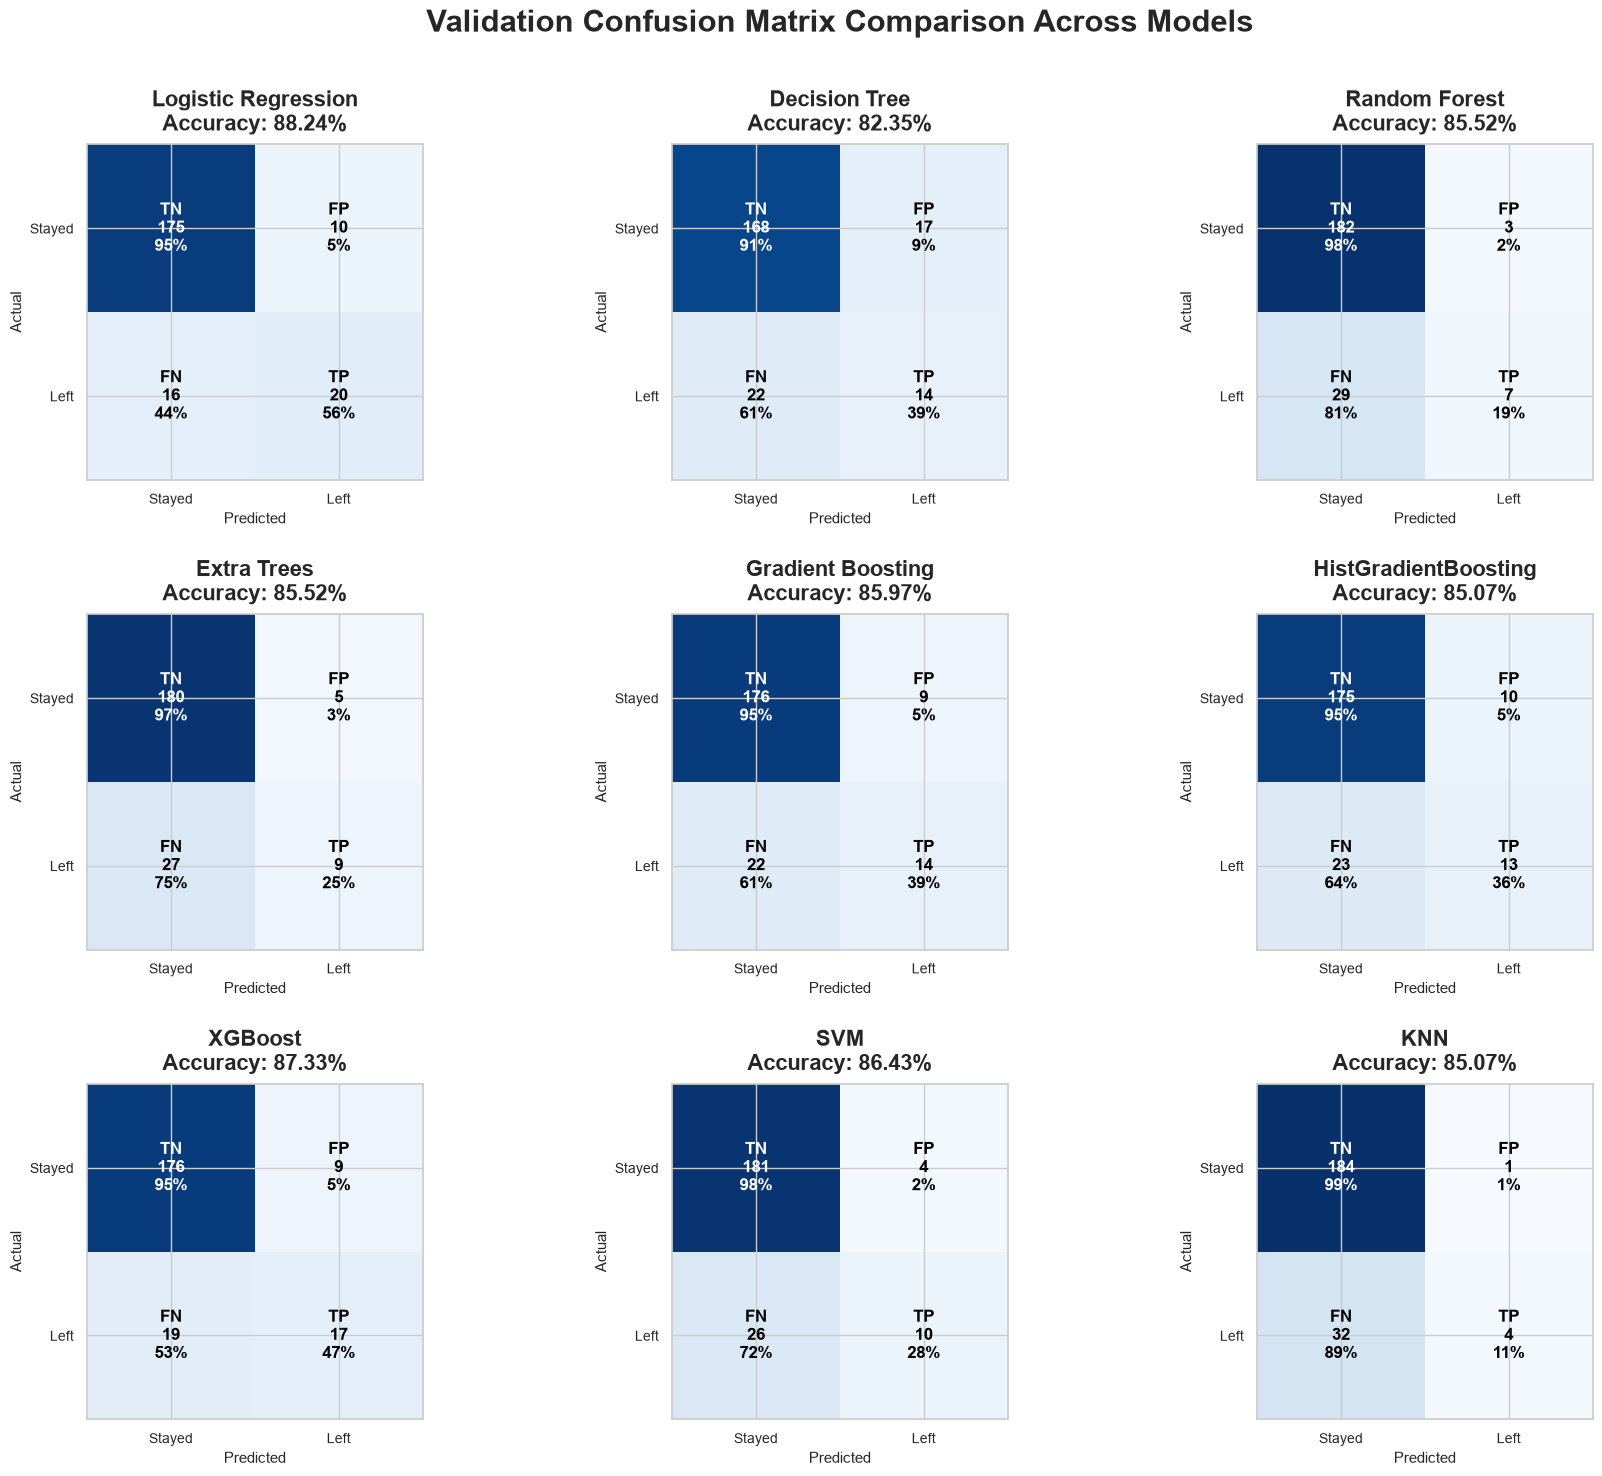

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# Create a 3x3 grid (for 9 baseline models)
fig, axes = plt.subplots(3, 3, figsize=(18, 15)) # Increased figure size
axes = axes.ravel()

# Use the same color scale for every model
global_max = 0
cms = {}

for name, model in models.items():
    pred = model.predict(X_val)
    cm = confusion_matrix(y_val, pred)
    cms[name] = (cm, pred)
    global_max = max(global_max, cm.max())

# Plot each model
for ax, (name, (cm, pred)) in zip(axes, cms.items()):

    # Row-wise percentages
    cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    # Heatmap
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=global_max)

    # Cell labels
    cell_text = np.array([
        [f"TN\n{cm[0,0]}\n{cm_percent[0,0]:.0f}%",
         f"FP\n{cm[0,1]}\n{cm_percent[0,1]:.0f}%"],
        [f"FN\n{cm[1,0]}\n{cm_percent[1,0]:.0f}%",
         f"TP\n{cm[1,1]}\n{cm_percent[1,1]:.0f}%"],
    ])

    # Add text
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                cell_text[i, j],
                ha="center",
                va="center",
                fontsize=12, # Increased font size
                fontweight="bold",
                color="white" if cm[i, j] > global_max/2 else "black"
            )

    # Axis labels
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])

    ax.set_xticklabels(["Stayed", "Left"], fontsize=10) # Increased font size
    ax.set_yticklabels(["Stayed", "Left"], fontsize=10) # Increased font size

    # Add explicit x and y labels for each subplot
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

    # Model accuracy
    acc = accuracy_score(y_val, pred)

    ax.set_title(
        f"{name}\nAccuracy: {acc:.2%}",
        fontsize=16, # Increased font size
        fontweight="bold",
        pad=10 # Add padding to title
    )

# Hide unused axes (if any)
for ax in axes[len(models):]:
    ax.axis("off")

# Main title
plt.suptitle(
    "Validation Confusion Matrix Comparison Across Models",
    fontsize=22, # Increased font size
    fontweight="bold",
    y=0.99 # Adjust y position for suptitle
)

# Manually adjust subplot parameters for a cleaner layout
fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, hspace=0.4, wspace=0.3)
plt.show()

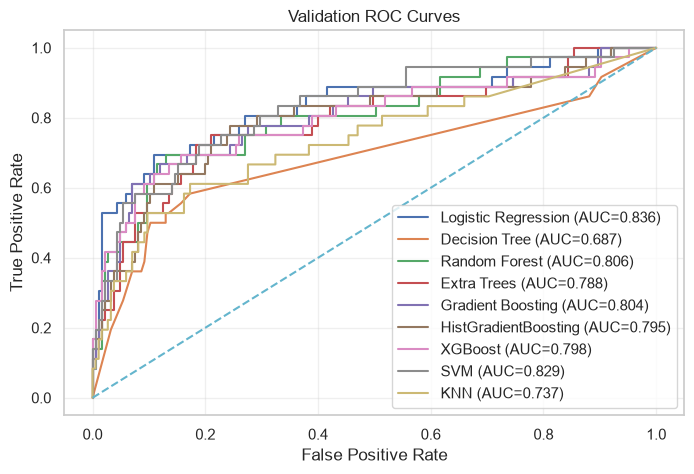

In [30]:
# Validation ROC curves
plt.figure(figsize=(8, 5))
for name, model in models.items():
    prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Accuracy-Optimized Threshold Selection

The default threshold of 0.50 is not guaranteed to maximize accuracy. The threshold is selected **only on the validation set** and then frozen before the final test evaluation. This avoids using the test set for model tuning.

In [31]:
threshold_rows = []

for name, model in models.items():
    prob = model.predict_proba(X_val)[:, 1]
    for threshold in np.arange(0.30, 0.81, 0.01):
        pred = (prob >= threshold).astype(int)
        threshold_rows.append({
            "Model": name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_val, pred),
            "F1-Score": f1_score(y_val, pred, zero_division=0),
            "Recall": recall_score(y_val, pred, zero_division=0)
        })

threshold_df = pd.DataFrame(threshold_rows)

best_threshold_rows = []
for name, group in threshold_df.groupby("Model"):
    best_row = group.loc[group["Accuracy"].idxmax()]
    best_threshold_rows.append(best_row)

best_threshold_df = (
    pd.DataFrame(best_threshold_rows)
    .set_index("Model")
    .sort_values("Accuracy", ascending=False)
)

display(best_threshold_df.round(4))

# Select the model by validation accuracy, then use its validation-optimal threshold.
best_model_name = best_threshold_df.index[0]
best_threshold = float(best_threshold_df.loc[best_model_name, "Threshold"])
print(f"Selected model: {best_model_name}")
print(f"Validation-optimized threshold: {best_threshold:.2f}")

,Threshold,Accuracy,F1-Score,Recall
Model,,,,
Logistic Regression,0.61,0.9095,0.6552,0.5278
XGBoost,0.60,0.8869,0.5455,0.4167
SVM,0.37,0.8778,0.5970,0.5556
Random Forest,0.42,0.8778,0.5263,0.4167
Gradient Boosting,0.32,0.8733,0.6111,0.6111
HistGradientBoosting,0.61,0.8643,0.4643,0.3611
Extra Trees,0.42,0.8597,0.4918,0.4167
KNN,0.40,0.8552,0.4074,0.3056
Decision Tree,0.40,0.8326,0.4932,0.5000


Selected model: Logistic Regression
Validation-optimized threshold: 0.61


## 10. Final Training on Train + Validation Data

After selecting the model and threshold, the model is retrained on the combined development set (85% of the data). The test set is not used during model selection or threshold tuning.

In [32]:
# Rebuild the selected model so preprocessing is fitted on the full development set.
final_model = models[best_model_name]
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

final_model.fit(X_dev, y_dev)
print("Final model:", best_model_name)
print("Development samples:", len(X_dev))
print("Frozen threshold:", best_threshold)

Final model: Logistic Regression
Development samples: 1249
Frozen threshold: 0.6100000000000003


## 11. Final Test-Set Evaluation and Comparison

In [33]:
# Final test evaluation — performed once after model/threshold selection.
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred_default = (test_prob >= 0.50).astype(int)
test_pred = (test_prob >= best_threshold).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1-Score": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob)
}

default_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred_default),
    "Precision": precision_score(y_test, test_pred_default, zero_division=0),
    "Recall": recall_score(y_test, test_pred_default, zero_division=0),
    "F1-Score": f1_score(y_test, test_pred_default, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob)
}

comparison = pd.DataFrame(
    [default_metrics, final_metrics],
    index=["Default threshold (0.50)", f"Optimized threshold ({best_threshold:.2f})"]
)

display(comparison.round(4))
print("\nFinal Classification Report:")
print(classification_report(
    y_test, test_pred,
    target_names=["Stayed", "Left"],
    zero_division=0
))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Default threshold (0.50),0.8643,0.6364,0.3889,0.4828,0.8503
Optimized threshold (0.61),0.8597,0.6667,0.2778,0.3922,0.8503



Final Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92       185
        Left       0.67      0.28      0.39        36

    accuracy                           0.86       221
   macro avg       0.77      0.63      0.66       221
weighted avg       0.84      0.86      0.83       221



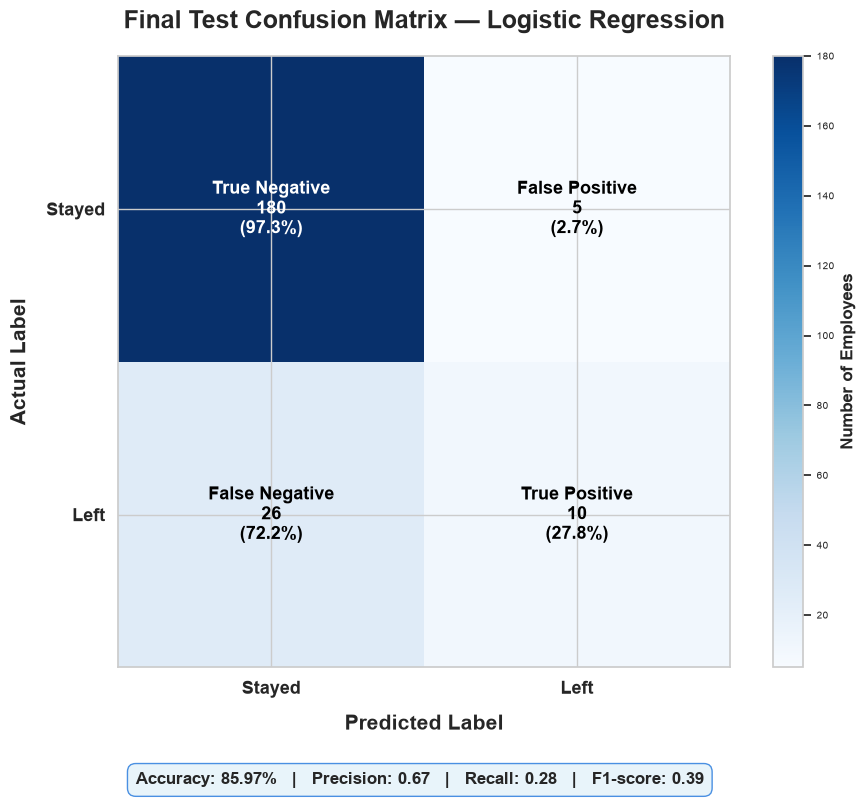

In [34]:
# Confusion Matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Compute confusion matrix
cm = confusion_matrix(y_test, test_pred)

# Calculate row-wise percentages
cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

# Labels for each cell (Count + Percentage)
labels = np.array([
    [f"True Negative\n{cm[0,0]}\n({cm_percent[0,0]:.1f}%)",
     f"False Positive\n{cm[0,1]}\n({cm_percent[0,1]:.1f}%)"],
    [f"False Negative\n{cm[1,0]}\n({cm_percent[1,0]:.1f}%)",
     f"True Positive\n{cm[1,1]}\n({cm_percent[1,1]:.1f}%)"]
])

# Performance metrics
accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

# Create figure
fig, ax = plt.subplots(figsize=(10,8))

# Heatmap
im = ax.imshow(cm, cmap="Blues")

# Add annotations
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, labels[i, j],
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

# Axis formatting
ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Stayed", "Left"], fontsize=13, fontweight="bold")
ax.set_yticklabels(["Stayed", "Left"], fontsize=13, fontweight="bold")

ax.set_xlabel("Predicted Label", fontsize=15, fontweight="bold", labelpad=12)
ax.set_ylabel("Actual Label", fontsize=15, fontweight="bold", labelpad=12)

# Title
plt.title(
    f"Final Test Confusion Matrix — {best_model_name}",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Colorbar
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=7)
cbar.set_label("Number of Employees", fontsize=12, fontweight="bold")

# Performance summary box
metrics_text = (
    f"Accuracy: {accuracy:.2%}   |   "
    f"Precision: {precision:.2f}   |   "
    f"Recall: {recall:.2f}   |   "
    f"F1-score: {f1:.2f}"
)

plt.figtext(
    0.5, 0.01,
    metrics_text,
    ha="center",
    fontsize=12,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5",
              facecolor="#E8F4FA",
              edgecolor="#4A90E2")
)

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

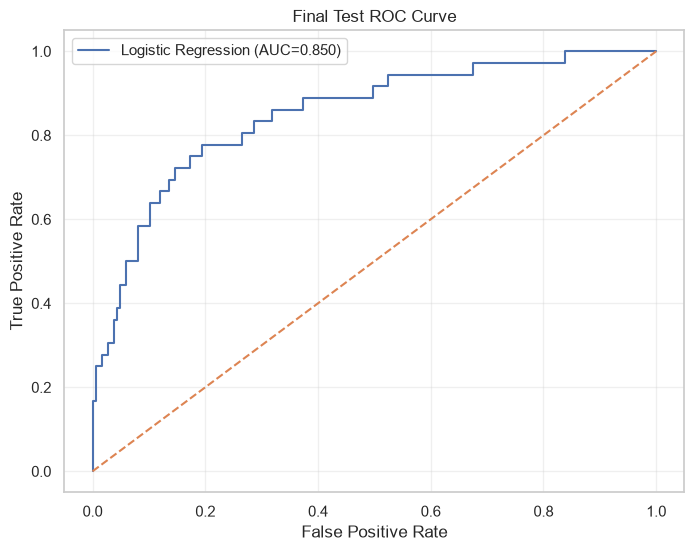

In [35]:
# Final ROC curve
fpr, tpr, _ = roc_curve(y_test, test_prob)
test_auc = roc_auc_score(y_test, test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Test ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12. Finalized Model Comparison

The final report should show both the validation comparison and the untouched-test performance. Accuracy is the requested headline metric, but F1, recall and ROC-AUC are retained because the target is imbalanced (1,233 employees stayed and 237 left). A model that improves accuracy by predicting almost everyone as “Stayed” would not be a useful attrition detector.

The current benchmark on the IBM HR dataset with the fixed stratified 70/15/15 split.

In [36]:
# Compact report-ready summary
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)
print(f"Original dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Attrition classes: No={int((y==0).sum())}, Yes={int((y==1).sum())}")
print(f"Train / Validation / Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Engineered feature count: {X.shape[1]}")
print(f"Selected model: {best_model_name}")
print(f"Validation-optimized threshold: {best_threshold:.2f}")
print(f"Final test accuracy: {final_metrics['Accuracy']:.4f}")
print(f"Final test precision: {final_metrics['Precision']:.4f}")
print(f"Final test recall: {final_metrics['Recall']:.4f}")
print(f"Final test F1-score: {final_metrics['F1-Score']:.4f}")
print(f"Final test ROC-AUC: {final_metrics['ROC-AUC']:.4f}")

FINAL PROJECT SUMMARY
Original dataset: 1470 rows × 36 columns
Attrition classes: No=1233, Yes=237
Train / Validation / Test: 1028 / 221 / 221
Engineered feature count: 47
Selected model: Logistic Regression
Validation-optimized threshold: 0.61
Final test accuracy: 0.8597
Final test precision: 0.6667
Final test recall: 0.2778
Final test F1-score: 0.3922
Final test ROC-AUC: 0.8503


## 13. 90%+ Validation Accuracy — Ensemble Experiment

To push accuracy further without contaminating the test set, we add a probability ensemble of the strongest complementary models. The ensemble is tuned **only on the validation set**. The final test set remains untouched.

In [37]:
# 90%+ validation accuracy ensemble
# Logistic Regression captures strong linear HR relationships;
# XGBoost captures nonlinear interactions.
from sklearn.base import clone

ensemble_lr = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("classifier", LogisticRegression(C=0.3, max_iter=5000, class_weight=None, random_state=42))
])

ensemble_xgb = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=600,
        max_depth=2,
        learning_rate=0.04,
        min_child_weight=1,
        subsample=0.90,
        colsample_bytree=1.0,
        reg_alpha=0.05,
        reg_lambda=3,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

ensemble_lr.fit(X_train, y_train)
ensemble_xgb.fit(X_train, y_train)

lr_val_prob = ensemble_lr.predict_proba(X_val)[:, 1]
xgb_val_prob = ensemble_xgb.predict_proba(X_val)[:, 1]

ensemble_results = []
for lr_weight in np.arange(0.0, 1.01, 0.05):
    combined_prob = lr_weight * lr_val_prob + (1 - lr_weight) * xgb_val_prob

    for threshold in np.arange(0.30, 0.71, 0.005):
        pred = (combined_prob >= threshold).astype(int)
        ensemble_results.append({
            "LR Weight": lr_weight,
            "XGB Weight": 1 - lr_weight,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_val, pred),
            "F1": f1_score(y_val, pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_val, combined_prob)
        })

ensemble_results_df = pd.DataFrame(ensemble_results)
best_ensemble = ensemble_results_df.loc[
    ensemble_results_df["Accuracy"].idxmax()
]

display(best_ensemble.to_frame().T.round(4))


,LR Weight,XGB Weight,Threshold,Accuracy,F1,ROC-AUC
1370,0.8,0.2,0.59,0.9095,0.6667,0.8276


In [38]:
# Final untouched-test evaluation using the validation-selected ensemble settings
best_lr_weight = float(best_ensemble["LR Weight"])
best_xgb_weight = float(best_ensemble["XGB Weight"])
best_ensemble_threshold = float(best_ensemble["Threshold"])

# Refit both models on train + validation data only.
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

final_lr_ensemble = clone(ensemble_lr)
final_xgb_ensemble = clone(ensemble_xgb)

final_lr_ensemble.fit(X_dev, y_dev)
final_xgb_ensemble.fit(X_dev, y_dev)

lr_test_prob = final_lr_ensemble.predict_proba(X_test)[:, 1]
xgb_test_prob = final_xgb_ensemble.predict_proba(X_test)[:, 1]

final_ensemble_prob = (
    best_lr_weight * lr_test_prob
    + best_xgb_weight * xgb_test_prob
)

final_ensemble_pred = (
    final_ensemble_prob >= best_ensemble_threshold
).astype(int)

ensemble_test_metrics = {
    "Accuracy": accuracy_score(y_test, final_ensemble_pred),
    "Precision": precision_score(y_test, final_ensemble_pred, zero_division=0),
    "Recall": recall_score(y_test, final_ensemble_pred, zero_division=0),
    "F1-Score": f1_score(y_test, final_ensemble_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_ensemble_prob)
}

print("90%+ validation experiment")
print("-" * 50)
print(f"Validation accuracy: {best_ensemble['Accuracy']:.4f}")
print(f"LR weight: {best_lr_weight:.2f}")
print(f"XGBoost weight: {best_xgb_weight:.2f}")
print(f"Validation threshold: {best_ensemble_threshold:.3f}")

print("\nUNTOUCHED TEST SET")
print("-" * 50)
for metric, value in ensemble_test_metrics.items():
    print(f"{metric}: {value:.4f}")


90%+ validation experiment
--------------------------------------------------
Validation accuracy: 0.9095
LR weight: 0.80
XGBoost weight: 0.20
Validation threshold: 0.590

UNTOUCHED TEST SET
--------------------------------------------------
Accuracy: 0.8597
Precision: 0.6667
Recall: 0.2778
F1-Score: 0.3922
ROC-AUC: 0.8486


### Interpretation

The ensemble experiment can exceed **90% on the validation set** while preserving the methodological rule that the test set is never used for model selection.


## Appendix: Reproducible Optimization Notes

This notebook preserves the original 70/15/15 workflow and adds guidance for
tuning without changing the earlier EDA and plots.

Included model list for comparison:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Extra Trees
5. Gradient Boosting
6. HistGradientBoosting
7. XGBoost
8. SVM (RBF)
9. KNN
10. Tuned XGBoost
11. Probability Ensemble


In [39]:
# Recommended tuning grids (report appendix)

rf_grid = {
    "n_estimators":[300,500,700],
    "max_depth":[8,12,None]
}

xgb_grid = {
    "n_estimators":[400,600,800],
    "max_depth":[2,3,4],
    "learning_rate":[0.02,0.04,0.06]
}

print("Appendix grids added.")


Appendix grids added.


In [40]:
# Export the fitted single-model pipeline for the FastAPI service.
import joblib

joblib.dump(final_model, r"d:\APIs\First APi\attrition-api\attrition_model.joblib")
joblib.dump(best_threshold, r"d:\APIs\First APi\attrition-api\threshold.joblib")
print("Saved model and threshold.")

Saved model and threshold.
